<a href="https://colab.research.google.com/github/Agussatya87/Analisis_Sentimen_X_Pasca_Pertandingan_PialaAFC23/blob/main/Analisis_Sentimen_PialaAFC23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ANALISIS SENTIMEN PASCA PERTANDINGAN PIALA AFC23**


In [ ]:
!pip install Sastrawi

In [ ]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("bola.csv")
df

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1785270951460098162,Tue Apr 30 11:33:20 +0000 2024,0,Tapi ngomong-ngomong gimana pertandingan semal...,1785271212085805366,NaN,Cerita_Parapuan,in,NaN,0,0,0,https://twitter.com/Cerita_Parapuan/status/178...,1349286188402712576,Cerita_Parapuan
1,1785268170875711905,Tue Apr 30 11:21:15 +0000 2024,0,Harusnya ikutan sok sok sering jatuh juga lah ...,1785268170875711905,NaN,NaN,in,Bandung,0,0,0,https://twitter.com/renaerlianisyah/status/178...,135391893,renaerlianisyah
2,1785268713362747580,Tue Apr 30 11:23:24 +0000 2024,0,Wasitnya kayak tukang parkir #indonesiavsuzbek...,1785268713362747580,NaN,NaN,in,NaN,0,0,0,https://twitter.com/ZulidarRizka/status/178526...,1296394153996083201,ZulidarRizka
3,1785269955820454323,Tue Apr 30 11:28:20 +0000 2024,0,Hhmm double kill untuk hari ini #indonesiavsuz...,1785269955820454323,NaN,NaN,in,NaN,0,0,0,https://twitter.com/ZulidarRizka/status/178526...,1296394153996083201,ZulidarRizka
4,1785255468463767957,Tue Apr 30 10:30:46 +0000 2024,1,Nemu stts we aa teman... Bikin gemes wasit² pe...,1785255468463767957,https://pbs.twimg.com/media/GMaAW-fbgAA_hdu.jpg,NaN,in,"Malang, Jawa Timur",0,0,0,https://twitter.com/agus_mn12/status/178525546...,2553942204,agus_mn12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,1784931682686308663,Mon Apr 29 13:04:10 +0000 2024,1,STIAP AKUN BARU PUNYA HAK MAXWIN!! #tinder88 #...,1784931682686308663,https://pbs.twimg.com/media/GMVZvrBbkAAmXA8.jpg,NaN,in,NaN,0,0,0,https://twitter.com/tinderdelapan2/status/1784...,1756323828358086656,tinderdelapan2
499,1784931604013732023,Mon Apr 29 13:03:51 +0000 2024,2,Alun² Pamulang siap 🇲🇨️ #TimnasDay #TimnasIndo...,1784931604013732023,https://pbs.twimg.com/media/GMVZ0jRbkAA76sr.jpg,NaN,in,Jakarta,0,1,0,https://twitter.com/omkondre/status/1784931604...,33402402,omkondre
500,1784931398580858901,Mon Apr 29 13:03:02 +0000 2024,0,STIAP AKUN BARU PUNYA HAK MAXWIN!! #pepe4d #PE...,1784931398580858901,https://pbs.twimg.com/media/GMVZUq7bYAA1gaG.jpg,NaN,in,Indonesia,0,0,0,https://twitter.com/Pepe4dmenang/status/178493...,1756301121994268672,Pepe4dmenang
501,1784930276919120025,Mon Apr 29 12:59:13 +0000 2024,10,Suasana dlm stadion Panas bngt Masi sepi.. sec...,1784930438894751803,https://pbs.twimg.com/media/GMVYps3bEAAr2Ln.jpg,jumintenkoplak,in,"City Hopper, Travelholic",0,2,2,https://twitter.com/jumintenkoplak/status/1784...,280814251,jumintenkoplak


In [ ]:
df = df[['full_text']]
df

,full_text
0,Tapi ngomong-ngomong gimana pertandingan semal...
1,Harusnya ikutan sok sok sering jatuh juga lah ...
2,Wasitnya kayak tukang parkir #indonesiavsuzbek...
3,Hhmm double kill untuk hari ini #indonesiavsuz...
4,Nemu stts we aa teman... Bikin gemes wasit² pe...
...,...
498,STIAP AKUN BARU PUNYA HAK MAXWIN!! #tinder88 #...
499,Alun² Pamulang siap 🇲🇨️ #TimnasDay #TimnasIndo...
500,STIAP AKUN BARU PUNYA HAK MAXWIN!! #pepe4d #PE...
501,Suasana dlm stadion Panas bngt Masi sepi.. sec...


#Cleaning Data

In [ ]:
df = df.drop_duplicates(subset=['full_text'])

In [ ]:
df.duplicated().sum()

0

In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

full_text    0
dtype: int64

In [ ]:
df.shape

(503, 1)

In [ ]:
def clean_data_tweets(text):
  text = re.sub(r'@[A-Za-z0-9_]+', '', text)
  text = re.sub(r'#\w+', '', text)
  text = re.sub(r'RT[\s]+', '', text)
  text = re.sub(r'https?://\S+', '', text)

  text = re.sub(r'[^A-Za-z0-9 ]', '', text)
  text = re.sub(r'\s+', ' ', text).strip()

  return text

df['full_text'] = df['full_text'].apply(clean_data_tweets)

In [ ]:
df['full_text'] = df['full_text'].str.lower()

In [ ]:
df.to_csv("sementara.csv", index=False)

#Preprocessing

In [ ]:
norm = {" yg ": " yang ", ' gak ' : ' tidak ', ' sy ': ' saya ', ' goblok ': ' bodoh ', ' nobar ' : ' nonton bareng', ' mantab ': ' keren ', ' lu ' : ' kamu ', ' sm ': ' sama ', ' ga ' : ' tidak ', ' wasitnya ' : ' wasit '}

def normalisasi(str_text):
  for i in norm:
    str_text = str_text.replace(i, norm[i])
  return str_text

df['full_text'] = df['full_text'].apply(lambda x: normalisasi(x))
df

,full_text
0,tapi ngomongngomong gimana pertandingan semala...
1,harusnya ikutan sok sok sering jatuh juga lah ...
2,wasitnya kayak tukang parkir
3,hhmm double kill untuk hari ini
4,nemu stts we aa teman bikin gemes wasit pertan...
...,...
498,stiap akun baru punya hak maxwin semangat indo...
499,alun pamulang siap
500,stiap akun baru punya hak maxwin semangat indo...
501,suasana dlm stadion panas bngt masi sepi secar...


In [ ]:
#stopword
import Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory, StopWordRemover, ArrayDictionary
more_stop_word = ["tidak"]

stop_words = StopWordRemoverFactory().get_stop_words()
stop_words.extend(more_stop_word)

new_array = ArrayDictionary(stop_words)
stop_words_remover_new = StopWordRemover(new_array)

def stopwords(str_text):
  str_text = stop_words_remover_new.remove(str_text)
  return str_text

df['full_text'] = df['full_text'].apply(lambda x: stopwords(x))
df.head()


,full_text
0,ngomongngomong gimana pertandingan semalam kaw...
1,harusnya ikutan sok sok sering jatuh lah serin...
2,wasitnya kayak tukang parkir
3,hhmm double kill hari
4,nemu stts we aa teman bikin gemes wasit pertan...


In [ ]:
# Splitting kata
split_kata = df['full_text'].apply(lambda x:x.split())
split_kata

0      [ngomongngomong, gimana, pertandingan, semalam...
1      [harusnya, ikutan, sok, sok, sering, jatuh, la...
2                      [wasitnya, kayak, tukang, parkir]
3                             [hhmm, double, kill, hari]
4      [nemu, stts, we, aa, teman, bikin, gemes, wasi...
                             ...                        
498    [stiap, akun, baru, punya, hak, maxwin, semang...
499                               [alun, pamulang, siap]
500    [stiap, akun, baru, punya, hak, maxwin, semang...
501    [suasana, dlm, stadion, panas, bngt, masi, sep...
502                                   [bantu, aku, bang]
Name: full_text, Length: 503, dtype: object

In [ ]:
# Stemming
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def stemming(text_stem):
  factory = StemmerFactory()
  stemmer = factory.create_stemmer()
  do = []

  for a in text_stem:
    dt = stemmer.stem(a)
    do.append(dt)

  d_clean=[]
  d_clean=" ".join(do)
  print(d_clean)
  return d_clean

split_kata = split_kata.apply(stemming)

split_kata.to_csv("data_hasil_prepocessing.csv", index=False)

ngomongngomong gimana tanding malam kawan puan
harus ikut sok sok sering jatuh lah sering jatuh sendiri main indo mesti ikut sering jatuh bola bukan soal skill mampu pintar tentang banyak apa kecoh lawan
wasit kayak tukang parkir
hhmm double kill hari
nemu stts we aa teman bikin gemes wasit tanding
kata shin taeyong usai timnas u23 indonesia kalah uzbekistan baca lengkap
indonesia lolos final bandar rugi dong wasit aman boss kondisi begitu tanding malam jalan
kata media asing soal kalah indonesia uzbekistan n
shin taeyong rasa rugi atas imbang laku wasit shen yinhao sebut lama tanding semifinal piala asia u23 bagaimana turut
ribu suporter tunduk lesu tahu timnas indonesia kalah lawan uzbekistan senin malam
langkah skuad garuda u23 paksa henti kalah skor 02 uzbekistan kalah maaf jika lihat juang tim nasional indonesia sejati debut turnamen bola sepak se asia
nama selebgram jerome polin dadak trending media sosial usai kalah timnas u23 indonesia lawan uzbekistan laga semifinal piala asia

#Translate

In [ ]:
!pip install googletrans

In [ ]:
from googletrans.client import Translator
translator =  Translator()

In [ ]:
def translate_to_english(text):
    translator = Translator()
    translation = translator.translate(text, dest='en')
    return translation.text

df['tweet_eng'] = df['full_text'].apply(translate_to_english)


In [ ]:
df

,full_text,tweet_eng
0,ngomongngomong gimana pertandingan semalam kaw...,Talking about how the match last night Puan's ...
1,harusnya ikutan sok sok sering jatuh lah serin...,Supposedly the pretentious pretentious often f...
2,wasitnya kayak tukang parkir,the referee is like a parking attendant
3,hhmm double kill hari,hhmm double kill day
4,nemu stts we aa teman bikin gemes wasit pertan...,found STTS We Aa Friends Make the referee's re...
...,...,...
498,stiap akun baru punya hak maxwin semangat indo...,"Every new account has Maxwin Rights, the spiri..."
499,alun pamulang siap,Pamulang Alun is ready
500,stiap akun baru punya hak maxwin semangat indo...,every new account has the rights of Maxwin Sem...
501,suasana dlm stadion panas bngt masi sepi emang...,The atmosphere in a hot stadium is still quiet...


#Labeling

In [ ]:
!pip install tweet-preprocessor
!pip install textblob
!pip install wordcloud
!pip install nltk

In [ ]:
import preprocessor as p
from textblob import TextBlob
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
data_tweet = list(df['tweet_eng'])
polaritas = 0

status=[]
total_positif=total_negatif=total_netral= total = 0

for i, tweet in enumerate(data_tweet):
  analysis = TextBlob(tweet)
  polaritas += analysis.polarity

  if analysis.sentiment.polarity > 0.0:
    total_positif += 1
    status.append('Positif')
  elif analysis.sentiment.polarity == 0.0:
    total_netral += 1
    status.append('Netral')
  else:
    total_negatif +=1
    status.append('Negatif')

  total +=1

print(f'Hasil Analisis:\nPositif = {total_positif}\nNegatif = {total_negatif}\nNetral = {total_netral}')
print(f'Total Data : {total}')

Hasil Analisis:
Positif = 186
Negatif = 60
Netral = 257
Total Data : 503


In [ ]:
df['klasifikasi'] = status
df.to_csv("hasil_analisis(textblob).csv", index=False)

#Visualisasi

In [ ]:
from wordcloud import WordCloud, STOPWORDS

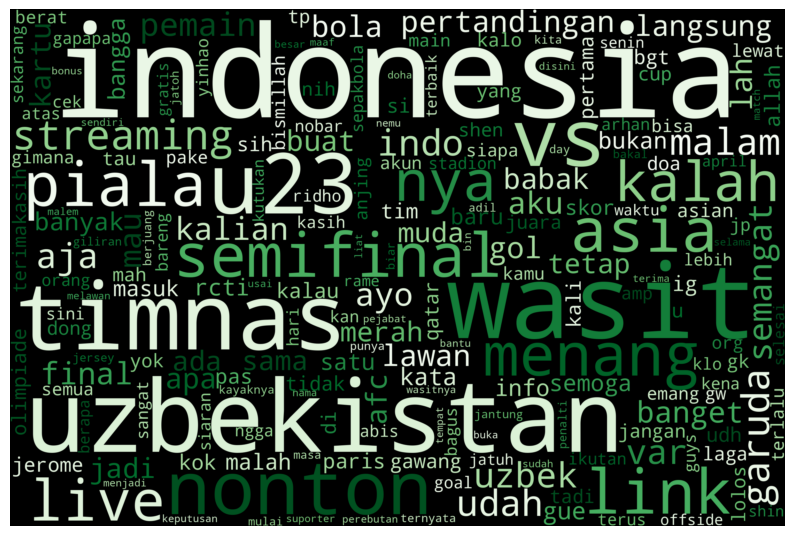

In [ ]:
def plot_cloud(wordcloud):
  plt.figure(figsize=(10, 8))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.show()

all_words = ' '.join([tweets for tweets in df['full_text']])

wordcloud = WordCloud(
    width=3000,
    height=2000,
    random_state=3,
    background_color='black',
    colormap='Greens_r',
    collocations=False,
    stopwords=STOPWORDS
).generate(all_words)

plot_cloud(wordcloud)

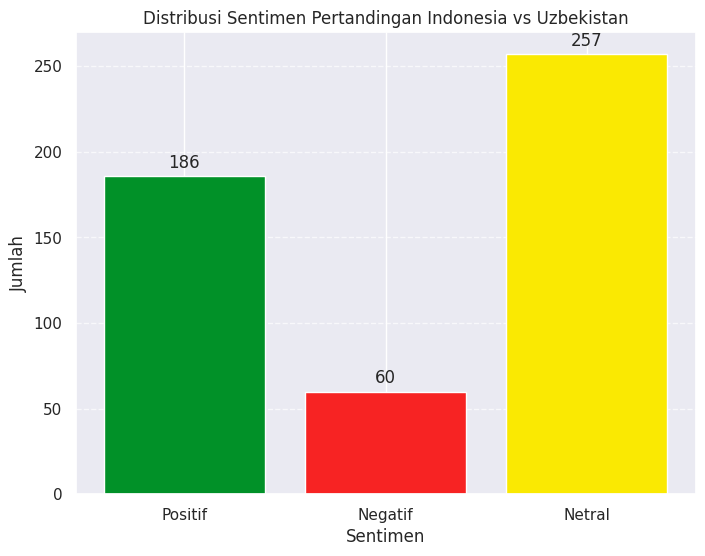

In [ ]:
import seaborn as sns
sns.set_theme()

labels = ['Positif', 'Negatif', 'Netral']
counts = [total_positif, total_negatif, total_netral]

def show_bar_chart (labels, counts, title):
  fig, ax = plt.subplots (figsize=(8, 6))
  bars = ax.bar (labels, counts, color=['#019128', '#f72323', '#fae902'])
  for bar, count in zip (bars, counts):
    height = bar.get_height()
    ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

  ax.grid(axis='y', linestyle='--', alpha=0.7)
  ax.set_xlabel('Sentimen' )
  ax.set_ylabel('Jumlah')
  ax.set_title(title)

  plt.show()

show_bar_chart (labels, counts, "Distribusi Sentimen Pertandingan Indonesia vs Uzbekistan")

#Naive Bayes

In [ ]:
dataset = df.drop(['full_text'], axis=1, inplace=False)
dataset = [tuple(x) for x in dataset.to_records(index=False)]

In [ ]:
import random

set_positif = []
set_negatif = []
set_netral = []

for n in dataset:
    if (n[1] == 'Positif'):
      set_positif.append(n)
    elif (n[1] == 'Negatif'):
      set_negatif.append(n)
    else:
      set_netral.append(n)
set_positif = random. sample (set_positif, k=int(len(set_positif)/2))
set_negatif = random. sample (set_negatif, k=int(len(set_negatif)/2))
set_netral = random. sample (set_netral, k=int(len(set_netral)/2))

train = set_positif + set_negatif + set_netral

train_set = []

for n in train:
  train_set.append(n)

In [ ]:
from textblob.classifiers import NaiveBayesClassifier

cls = NaiveBayesClassifier(train_set)
print("Test Akurasi : ", cls.accuracy(dataset))

Test Akurasi :  0.7415506958250497


In [ ]:
#Labeling
data_tweet = list(df['tweet_eng'])
polaritas = 0

status = []
total_positif = total_negatif = total_netral = total = 0

for i, tweet in enumerate(data_tweet):
    analysis = TextBlob (tweet, classifier=cls)
    if analysis.classify() == 'Positif':
      total_positif += 1
    elif analysis.classify() == 'Netral':
      total_netral += 1
    else:
      total_negatif += 1

    status.append(analysis.classify())
    total += 1

print (f'\nHasil Analisis Data: \nPositif = {total_positif}\nNetral = {total_netral}\nNegatif = {total_negatif}')
print(f'\nTotal Data: {total}')


Hasil Analisis Data: 
Positif = 146
Netral = 341
Negatif = 16

Total Data: 503


In [ ]:
status=pd.DataFrame({"Klasifikasi Bayes": status})
df['klasifikasi_bayes'] = status

In [ ]:
df

,full_text,tweet_eng,klasifikasi,klasifikasi_bayes
0,ngomongngomong gimana pertandingan semalam kaw...,Talking about how the match last night Puan's ...,Netral,Netral
1,harusnya ikutan sok sok sering jatuh lah serin...,Supposedly the pretentious pretentious often f...,Negatif,Negatif
2,wasitnya kayak tukang parkir,the referee is like a parking attendant,Positif,Netral
3,hhmm double kill hari,hhmm double kill day,Netral,Netral
4,nemu stts we aa teman bikin gemes wasit pertan...,found STTS We Aa Friends Make the referee's re...,Netral,Netral
...,...,...,...,...
498,stiap akun baru punya hak maxwin semangat indo...,"Every new account has Maxwin Rights, the spiri...",Positif,Netral
499,alun pamulang siap,Pamulang Alun is ready,Positif,Netral
500,stiap akun baru punya hak maxwin semangat indo...,every new account has the rights of Maxwin Sem...,Positif,Netral
501,suasana dlm stadion panas bngt masi sepi emang...,The atmosphere in a hot stadium is still quiet...,Positif,Netral


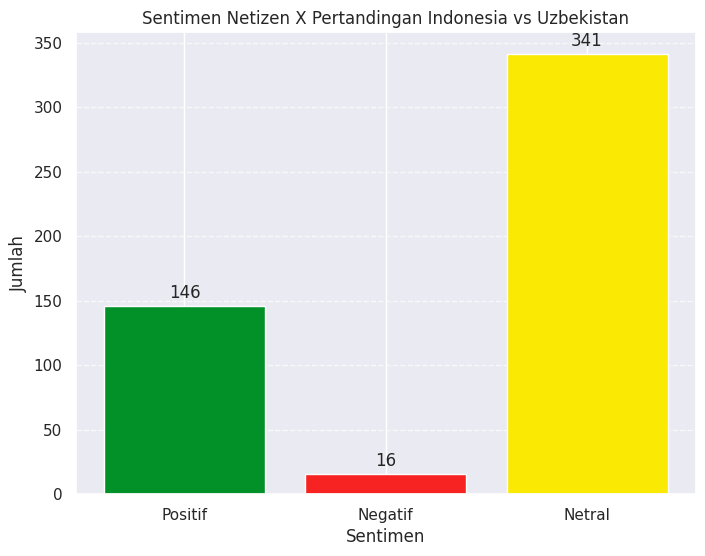

In [ ]:
import seaborn as sns
sns.set_theme()

labels = ['Positif', 'Negatif', 'Netral']
counts = [total_positif, total_negatif, total_netral]

def show_bar_chart (labels, counts, title):
  fig, ax = plt.subplots (figsize=(8, 6))
  bars = ax.bar (labels, counts, color=['#019128', '#f72323', '#fae902'])
  for bar, count in zip (bars, counts):
    height = bar.get_height()
    ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

  ax.grid(axis='y', linestyle='--', alpha=0.7)
  ax.set_xlabel('Sentimen' )
  ax.set_ylabel('Jumlah')
  ax.set_title(title)

  plt.show()

show_bar_chart (labels, counts, "Sentimen Netizen X Pertandingan Indonesia vs Uzbekistan")

In [ ]:
data_eval = [tuple(x) for x in df.to_records (index=False)]

for n in data_eval:
    if len(n) >= 4:
      if n[2] != n[3]:
        print (f'Text: {n[0]}\nClassifier: {n [2]}\nClassifier Bayes: {n[3]} \n')
    else:
      print("Tuple tidak memiliki cukup elemen.")

Text: wasitnya kayak tukang parkir
Classifier: Positif
Classifier Bayes: Netral 

Text: indonesia lolos final bandar rugi dong wasit aman boss kondisikan begitulah pertandingan semalam berjalan
Classifier: Positif
Classifier Bayes: Netral 

Text: kata media asing soal kekalahan indonesia uzbekistan n
Classifier: Negatif
Classifier Bayes: Netral 

Text: shin taeyong merasakan kerugian atas imbangnya perlakuan wasit shen yinhao tersebut selama pertandingan semifinal piala asia u23 bagaimana menurutmu
Classifier: Netral
Classifier Bayes: Positif 

Text: ribuan suporter tertunduk lesu mengetahui timnas indonesia kalah melawan uzbekistan senin malam
Classifier: Netral
Classifier Bayes: Positif 

Text: minimal kalo offside garis lahhh menunjukan kalo offside liga besar kok yah wasit se bodoh
Classifier: Negatif
Classifier Bayes: Positif 

Text: polo timnas indonesia ready kawan nonton barengmu berminat menghubungi admin
Classifier: Positif
Classifier Bayes: Netral 

Text: timnas indonesia u2

In [ ]:
df.to_csv("data_hasil_analisis.csv", index=False)